In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
user='barber.527'
in_path='/Users/'+user+'/Documents/Rojas_Lab/data'
out_path='/Users/'+user+'/Documents/GitHub/Rojas_lab_drafts/outputs'
expt_id = '/250520_ponA_sigI_western'
data=[]
with open(in_path+expt_id+expt_id+'_data_cumulative.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        data.append(row) # Data should be saved in UTF-8 format
        line_count += 1
print(data)

[['5/20/25', 'PBP1', 'SigA'], ['0', '492.43845', '2985.704708'], ['10', '517.6674', '2873.556919'], ['20', '713.106775', '3451.220832'], ['30', '754.953175', '3182.344331'], ['40', '824.22455', '3405.567101'], ['60', '901.98045', '3580.847366']]


In [3]:
cols=['Date', 'Stain', 'Intensity' , 'Time (min)']
df=pd.DataFrame(columns=cols)
dates=['5/20/25']
for line in data:
    if line[0] in dates:
        temp_date=line[0]
        temp_prots=line[1:]
    elif line[0]!='':
        for ind in np.arange(1,len(line)):
            temp_data=[[temp_date, temp_prots[ind-1], float(line[ind]), float(line[0])]]
            temp_df=pd.DataFrame(columns=cols,data=temp_data)
            df=pd.concat([df,temp_df])       

Okay, instead we are going to separate different columns for different signals.

In [4]:
cols=['Date', 'Time (min)']+list(df.Stain.unique())
df1=pd.DataFrame(columns=cols)
dates=list(df.Date.unique())
for line in data:
    if line[0] in dates:
        temp_vals=line[:]
    elif line[0]!='':
        temp_data=[temp_vals[0], int(line[0])]
        for prot in cols[2:]:
            temp_ind=temp_vals.index(prot)
            temp_data+=[float(line[temp_ind])]
        temp_df=pd.DataFrame(columns=cols,data=[temp_data])
        df1=pd.concat([df1,temp_df])

In [5]:
df1.index=np.arange(len(df1))
df1['PBP1/SigA']=np.nan
temp_vals=np.nan*np.ones(len(df1))
for ind in range(len(df1)):
    date=df1['Date'][ind]
#     print(date)
    temp_df=df1[df1.Date==date]
    var1_norm=temp_df[temp_df['Time (min)']==0]['PBP1']
    var2_norm=temp_df[temp_df['Time (min)']==0]['SigA']
    temp_vals[ind]=df1['PBP1'][ind]/df1['SigA'][ind]/var1_norm*var2_norm
df1['PBP1/SigA norm']=temp_vals
df1['PBP1/SigA']=df1['PBP1']/df1['SigA']

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_88084/2343293136.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df=df1.groupby(['Time (min)']).mean()
/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_88084/2343293136.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sem is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df1=df1.groupby(['Time (min)']).sem()
/opt/anaconda3/envs/py_311/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/opt/anaconda3/envs/py_311/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: A

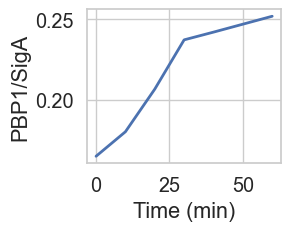

In [6]:
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.3)
sns.set_style('whitegrid')
temp_df=df1.groupby(['Time (min)']).mean()
temp_df1=df1.groupby(['Time (min)']).sem()
# sns.stripplot(data=df1,x='Time (min)', y='PBP1/SigA',dodge=True, color='k', edgecolor='black',
#                                  linewidth=1, alpha=0.1)
# sns.pointplot(data=df1,x='Time (min)',y='PBP1/SigA',estimator='mean',errorbar='se',lw=2.0)
sns.lineplot(data=df1,x='Time (min)',y='PBP1/SigA',estimator='mean',errorbar='se',err_style='bars',err_kws={'capsize':5.0,'capthick':2.0,'elinewidth':2.0},lw=2.0)
ax=plt.gca()
fig.savefig('./outputs/gels/intensity_cumulative_PBP1_sigA_timeplot_sigInull.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/gels/intensity_cumulative_PBP1_sigA_timeplot_sigInull.eps',bbox_inches='tight')

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_88084/4113414071.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df=df1.groupby(['Time (min)']).mean()
/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_88084/4113414071.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sem is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df1=df1.groupby(['Time (min)']).sem()


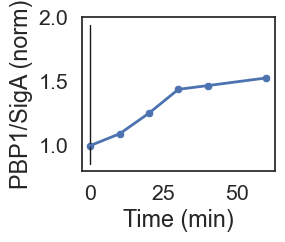

<Figure size 640x480 with 0 Axes>

In [7]:
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.4)
sns.set_style('white')
# sns.set_style('whitegrid')
temp_df=df1.groupby(['Time (min)']).mean()
temp_df1=df1.groupby(['Time (min)']).sem()
# sns.stripplot(data=df1,x='Time (min)', y='PBP1/SigA',dodge=True, color='k', edgecolor='black',
#                                  linewidth=1, alpha=0.1)
ax=plt.gca()
ax.axvline(ymin=0.05,ymax=0.95,x=0.0,color='k',linewidth=1.0)
# sns.pointplot(data=df1,x='Time (min)',y='PBP1/SigA norm',estimator='mean',errorbar='se',lw=2.0)
sns.lineplot(data=df1,x='Time (min)',y='PBP1/SigA norm',lw=2.0, markers='x',estimator=None)
sns.scatterplot(data=df1,x='Time (min)',y='PBP1/SigA norm', markers='o')
ax.set_ylim(ymin=0.8,ymax=2.0)
ax.set_ylabel('PBP1/SigA (norm)')
plt.show()
fig.savefig('./outputs/gels/intensity_cumulative_PBP1_sigA_norm_timeplot_sigInull_sigInull.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/gels/intensity_cumulative_PBP1_sigA_norm_timeplot_sigInull.eps',bbox_inches='tight')
plt.clf()

In [8]:
df1.groupby(['Time (min)'])['PBP1/SigA norm'].mean()

Time (min)
0     1.000000
10    1.092260
20    1.252785
30    1.438360
40    1.467408
60    1.527236
Name: PBP1/SigA norm, dtype: float64

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_34900/1154318444.py:4: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='PBP1',errorbar='se',capsize=0.5,errwidth=2.0)


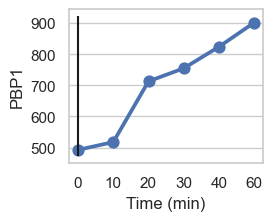

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_34900/1154318444.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='SigA',errorbar='se',capsize=0.5,errwidth=2.0)


<Figure size 640x480 with 0 Axes>

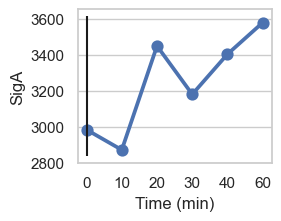

<Figure size 640x480 with 0 Axes>

In [12]:
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('whitegrid')
sns.pointplot(data=df1,x='Time (min)', y='PBP1',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_PBP1_sigInull.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_PBP1_sigInull.eps',bbox_inches='tight')
plt.show()
plt.clf()
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('whitegrid')
sns.pointplot(data=df1,x='Time (min)', y='SigA',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/gels/intensity_cumulative_SigA_sigInull.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/gels/intensity_cumulative_SigA_sigInull.eps',bbox_inches='tight')
plt.show()
plt.clf()